## **Machine Learning Aplicado a las Finanzas** 🚀
### **Sesión 7: Anomalías — Detección de Eventos y Fraude**

Andrés C. Medina Sanhueza  
Senior Data Scientist Engineer  
anmedinas@gmail.com

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from sklearn.ensemble import IsolationForest, RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import OneClassSVM
from sklearn.neighbors import LocalOutlierFactor
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.decomposition import PCA
from sklearn.metrics import (
    precision_recall_curve, roc_curve, roc_auc_score,
    average_precision_score, confusion_matrix,
    f1_score, fbeta_score, precision_score, recall_score
)
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression
import yfinance as yf
import warnings

sns.set_style('dark')
warnings.filterwarnings('ignore')
np.random.seed(42)

## 🍁 **`Motivación`**

### El problema de las anomalías en mercados financieros

Los mercados financieros generan continuamente millones de eventos: transacciones, cotizaciones, órdenes. La gran mayoría son legítimos y siguen patrones esperados. Una pequeña fracción, sin embargo, representa **eventos de alto impacto**: fraudes, manipulación de mercado, flash crashes, errores de datos o ataques de lavado de activos.

Este es el núcleo del problema de detección de anomalías:

> **La señal que más importa es la más rara.**

Esto crea tensiones fundamentales que distinguen este problema de la clasificación estándar:

| Problema estándar | Detección de anomalías |
|---|---|
| Clases balanceadas (~50/50) | Clases extremadamente desbalanceadas (<1% fraude) |
| Accuracy como métrica natural | Accuracy es engañosa — predecir "todo normal" da 99% |
| Etiquetas disponibles | Frecuentemente sin etiquetas (no supervisado) |
| Distribución estacionaria | Los patrones de fraude evolucionan — el atacante se adapta |
| Costos simétricos | Costo asimétrico: FN (fraude no detectado) >> FP (alarma falsa) |

### Casos de uso en finanzas

| Caso | Tipo de anomalía | Escala temporal | Consecuencia de no detectar |
|---|---|---|---|
| Fraude de tarjeta | Transacción individual | Segundos | Pérdida directa + daño reputacional |
| Lavado de activos | Patrón de transacciones | Días/semanas | Multas regulatorias (SBIF, CMF) |
| Manipulación de mercado | Patrón de órdenes | Minutos/horas | Distorsión de precios |
| Flash crash | Evento sistémico | Milisegundos | Pérdidas masivas en cascada |
| Error de datos | Precio/volumen incorrecto | Instantáneo | Señales de trading equivocadas |
| Insider trading | Patrón pre-anuncio | Días | Manipulación de precios |

### Conexión con el curso

Esta sesión conecta hacia atrás con **clustering/regímenes** (Sesión 6) — un cambio de régimen puede manifestarse como una anomalía — y hacia adelante con **desbalance y calibración** (Sesión 11) donde profundizaremos en modelos supervisados para fraude crediticio, y con **deep learning** (Sesión 12) donde los autoencoders son detectores de anomalías de primer nivel.

## 📚 **`Taxonomía de Anomalías`**

### Tres tipos fundamentales

Hawkins (1980) define una anomalía como *"una observación que difiere tanto de las demás que levanta sospechas de haber sido generada por un mecanismo diferente"*. Esta definición informal esconde tres tipos con implicancias muy distintas:

#### 1. Anomalía de Punto (*Point Anomaly*)
Una observación individual que es atípica respecto al resto del dataset.

$$x_i \text{ es anómala si } p(x_i) < \tau \quad \text{o} \quad d(x_i, \mathcal{X}) > \delta$$

**Ejemplo financiero:** una transacción de \$50,000 cuando el cliente típicamente gasta \$200.

#### 2. Anomalía Contextual (*Contextual Anomaly*)
Una observación que es normal en términos globales pero anómala dado su contexto (tiempo, ubicación, categoría).

**Ejemplo financiero:** un retiro de \$500 a las 3am en Tailandia para un cliente que siempre opera en Santiago en horario laboral.

#### 3. Anomalía Colectiva (*Collective Anomaly*)
Una secuencia de observaciones individuales que, aunque cada una puede ser normal, juntas constituyen una anomalía.

**Ejemplo financiero:** 50 transacciones de \$9,900 en un mes (estructuración — técnica de lavado para evadir el umbral de \$10,000 de reporte obligatorio).

### ¿Outlier estadístico = Anomalía financiera?

**No necesariamente.** Esta distinción es crítica en la práctica:

| Situación | Outlier estadístico | Anomalía financiera |
|---|---|---|
| CEO vende 10M en acciones (insider trading) | No — volumen no inusual | Sí — patrón pre-anuncio |
| Error tipográfico: precio = $0.001 | Sí — extremo estadístico | Sí — error de dato |
| Compra grande legítima por fondo institucional | Sí — volumen inusual | No — comportamiento esperado del cliente |
| Micro-transacciones de estructuración (smurfing) | No — individualmente normales | Sí — patrón colectivo |

La diferencia entre detectar outliers estadísticos y detectar anomalías financieramente relevantes es el **contexto del negocio** y el **perfil del cliente/activo**.

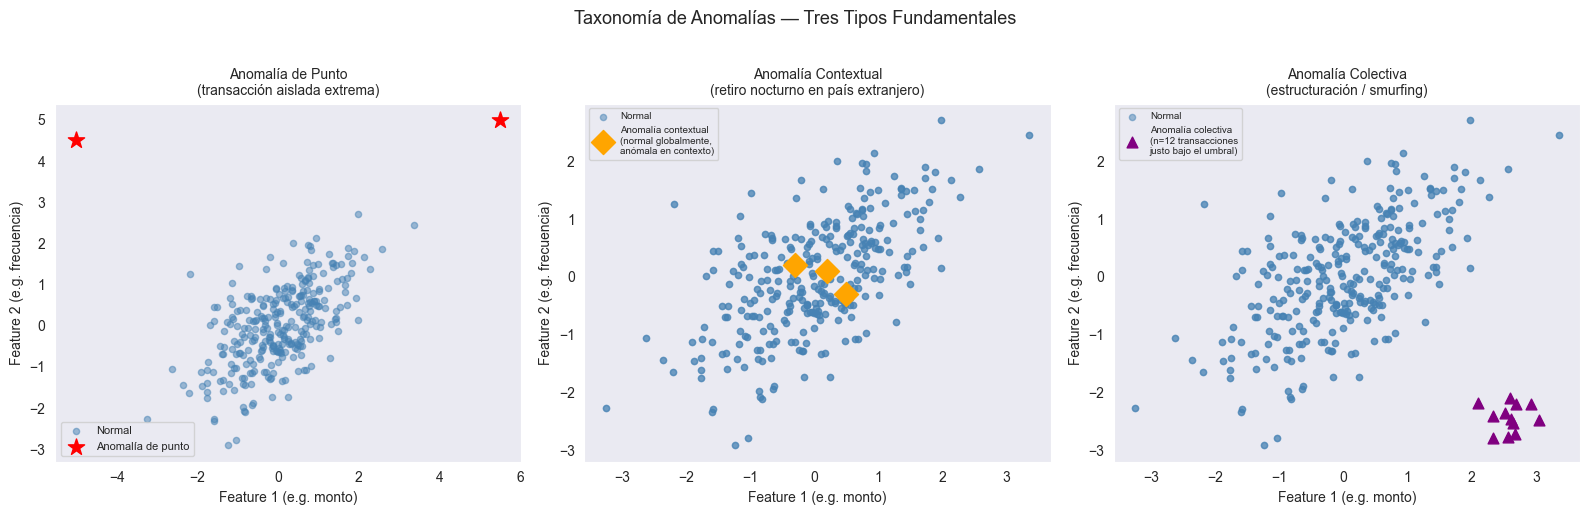

In [2]:
# Visualización de los 3 tipos de anomalías
np.random.seed(42)
n_normal = 300

# Datos normales: 2D gaussiana
X_normal = np.random.multivariate_normal([0, 0], [[1, 0.6],[0.6, 1]], n_normal)

# Anomalía de punto
X_point = np.array([[5.5, 5.0], [-5.0, 4.5]])

# Anomalía contextual: en zona densa del cluster pero en contexto incorrecto
X_ctx = np.array([[0.3, -0.2], [-0.1, 0.4]])  # serán marcadas por contexto externo

# Anomalía colectiva: grupo de puntos que individualmente parecen normales
X_coll = np.random.multivariate_normal([2.5, -2.5], [[0.05, 0],[0, 0.05]], 12)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax in axes:
    ax.scatter(X_normal[:, 0], X_normal[:, 1], c='steelblue', s=20, alpha=0.5, label='Normal')

# Panel 1: anomalía de punto
axes[0].scatter(X_point[:, 0], X_point[:, 1], c='red', s=150, marker='*',
                zorder=5, label='Anomalía de punto')
axes[0].set_title('Anomalía de Punto\n(transacción aislada extrema)', fontsize=10)
axes[0].legend(fontsize=8)

# Panel 2: anomalía contextual
axes[1].scatter(X_normal[:, 0], X_normal[:, 1], c='steelblue', s=20, alpha=0.5)
# Puntos estadísticamente normales pero en contexto incorrecto
ctx_pts = np.array([[0.2, 0.1], [0.5, -0.3], [-0.3, 0.2]])
axes[1].scatter(ctx_pts[:, 0], ctx_pts[:, 1], c='orange', s=150, marker='D',
                zorder=5, label='Anomalía contextual\n(normal globalmente,\nanómala en contexto)')
axes[1].set_title('Anomalía Contextual\n(retiro nocturno en país extranjero)', fontsize=10)
axes[1].legend(fontsize=7)

# Panel 3: anomalía colectiva
axes[2].scatter(X_normal[:, 0], X_normal[:, 1], c='steelblue', s=20, alpha=0.5)
axes[2].scatter(X_coll[:, 0], X_coll[:, 1], c='purple', s=60, marker='^',
                zorder=5, label=f'Anomalía colectiva\n(n={len(X_coll)} transacciones\njusto bajo el umbral)')
axes[2].set_title('Anomalía Colectiva\n(estructuración / smurfing)', fontsize=10)
axes[2].legend(fontsize=7)

for ax in axes:
    ax.set_xlabel('Feature 1 (e.g. monto)'); ax.set_ylabel('Feature 2 (e.g. frecuencia)')

plt.suptitle('Taxonomía de Anomalías — Tres Tipos Fundamentales', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

**Anomalía de Punto (izquierda):** los puntos rojos están claramente fuera de la nube principal — cualquier método detectará estas observaciones. Son los outliers que estadística clásica (IQR, z-score) captura bien.

**Anomalía Contextual (centro):** los puntos naranjas están *dentro* de la nube densa — estadísticamente parecen normales. Solo se vuelven sospechosos cuando se añade contexto: hora, país, historial del cliente. Los modelos puramente estadísticos los ignorarán; se necesitan features de contexto.

**Anomalía Colectiva (derecha):** los triángulos morados son individualmente normales y podrían pertenecer a la distribución principal. El patrón anómalo emerge solo al observarlos como grupo — 12 transacciones concentradas en un rango muy estrecho de montos. Requiere features de agregación temporal para ser detectada.

## 🎯 **`El Problema de Desbalance`**

### La falacia de la accuracy en fraude

En un dataset de tarjetas de crédito donde el 0.5% de las transacciones son fraude:

- **Modelo trivial** que predice siempre "no fraude": **Accuracy = 99.5%**
- **Recall de fraude = 0%** — no detecta ningún caso real

Este es el **paradox of accuracy**: en problemas con desbalance extremo, la métrica más intuitiva es la más engañosa.

### Métricas adecuadas para desbalance

#### Precision, Recall y F1

Dado un umbral de clasificación, definimos la matriz de confusión:

$$\text{Precision} = \frac{TP}{TP + FP} \qquad \text{Recall} = \frac{TP}{TP + FN} \qquad F_\beta = (1+\beta^2)\frac{\text{P} \cdot \text{R}}{\beta^2 \text{P} + \text{R}}$$

- **Precision:** de los que el modelo marca como fraude, ¿cuántos realmente lo son? → costo de investigar alarmas falsas
- **Recall:** de todos los fraudes reales, ¿cuántos detecta el modelo? → costo de fraudes no detectados
- **$F_2$**: pondera el Recall el doble — adecuado cuando FN (fraude sin detectar) es más costoso que FP (falsa alarma)

#### AUC-ROC vs AUC-PR

| Métrica | Qué mide | Problema con desbalance |
|---|---|---|
| **AUC-ROC** | Área bajo curva TPR vs FPR | Optimista: muchos TN inflan la curva |
| **AUC-PR** | Área bajo curva Precision vs Recall | Conservadora: refleja rendimiento sobre la clase rara |

> **Regla práctica:** en fraude y anomalías, reportar **AUC-PR** y **F2** siempre. AUC-ROC como métrica complementaria.

#### Baseline de AUC-PR

Un clasificador aleatorio en un dataset con prevalencia $p$ tiene:
$$\text{AUC-PR}_{\text{random}} = p$$

Con 0.5% de fraude, el baseline es **0.005** — muy diferente al 0.5 del AUC-ROC.

> **Nota:** Este clasificador, tambien se conoce como `DummyClassifier`, para ver cómo funciona, revisar la documentacion en `sklearn` 


Dataset: 10,000 transacciones
Fraude: 50 (0.50%)
Legítimo: 9,950 (99.50%)



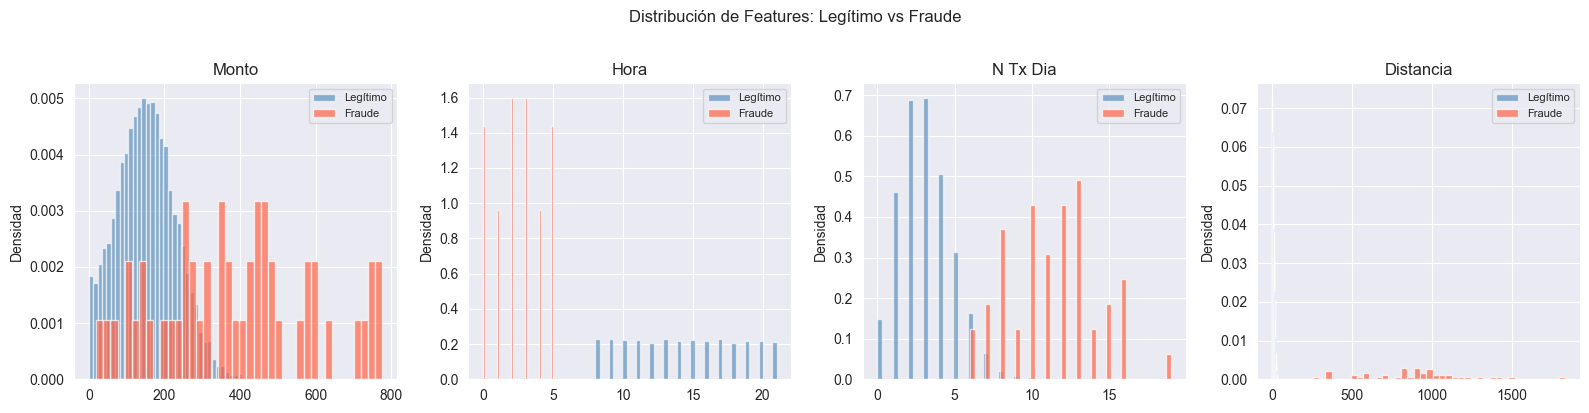

Modelo trivial (siempre 0):  Accuracy=0.9950  Recall_fraude=0.0000
→ La accuracy del 99.5% es ENGAÑOSA — detecta 0% de los fraudes


In [3]:
# Simulación de dataset de fraude con desbalance real
np.random.seed(42)
n_total    = 10_000
fraud_rate = 0.005          # 0.5% de fraude
n_fraud    = int(n_total * fraud_rate)
n_legit    = n_total - n_fraud

# Transacciones legítimas
legit = pd.DataFrame({
    'monto':      np.abs(np.random.normal(150, 80, n_legit)),
    'hora':       np.random.choice(range(8, 22), n_legit),
    'n_tx_dia':   np.random.poisson(3, n_legit),
    'distancia':  np.abs(np.random.normal(5, 10, n_legit)),
    'fraude':     0
})

# Transacciones fraudulentas (patrones distintos)
fraud = pd.DataFrame({
    'monto':      np.abs(np.random.normal(420, 200, n_fraud)),   # montos más altos
    'hora':       np.random.choice(range(0, 6), n_fraud),         # horas inusuales
    'n_tx_dia':   np.random.poisson(12, n_fraud),                 # muchas transacciones
    'distancia':  np.abs(np.random.normal(800, 300, n_fraud)),    # distancia geográfica alta
    'fraude':     1
})

df = pd.concat([legit, fraud], ignore_index=True).sample(frac=1, random_state=42)

print(f'Dataset: {len(df):,} transacciones')
print(f'Fraude: {df.fraude.sum()} ({df.fraude.mean():.2%})')
print(f'Legítimo: {(df.fraude==0).sum():,} ({1-df.fraude.mean():.2%})')
print()

# Comparar distribuciones legítimas vs fraude
features = ['monto', 'hora', 'n_tx_dia', 'distancia']
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for ax, feat in zip(axes, features):
    df[df.fraude==0][feat].hist(ax=ax, bins=40, alpha=0.6, color='steelblue',
                                 density=True, label='Legítimo')
    df[df.fraude==1][feat].hist(ax=ax, bins=40, alpha=0.7, color='tomato',
                                 density=True, label='Fraude')
    ax.set_title(feat.replace('_', ' ').title()); ax.set_ylabel('Densidad')
    ax.legend(fontsize=8)

plt.suptitle('Distribución de Features: Legítimo vs Fraude', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

# Mostrar el problema de accuracy
y = df['fraude'].values
X = df[features].values
X_sc = StandardScaler().fit_transform(X)

pred_trivial = np.zeros(len(y))   # predice siempre "no fraude"
acc_trivial  = (pred_trivial == y).mean()
rec_trivial  = recall_score(y, pred_trivial, zero_division=0)
print(f'Modelo trivial (siempre 0):  Accuracy={acc_trivial:.4f}  Recall_fraude={rec_trivial:.4f}')
print(f'→ La accuracy del {acc_trivial:.1%} es ENGAÑOSA — detecta 0% de los fraudes')

**Monto:** las transacciones legítimas se concentran en montos bajos (~100–200) con distribución sesgada a la derecha. El fraude muestra una distribución más plana y extendida hacia valores altos (~200–800), indicando que los fraudes tienden a involucrar montos mayores y más variados.

**Hora:** es el feature más discriminativo visualmente. Las transacciones legítimas se distribuyen durante el día (hora 10–22 aproximadamente), mientras que el fraude se concentra casi exclusivamente en madrugada (2–4 AM), cuando la supervisión es menor. Las distribuciones prácticamente no se solapan.

**N Tx Día:** las transacciones legítimas ocurren mayormente entre 1–5 por día. El fraude muestra actividad elevada: 8–15 transacciones diarias, consistente con la explotación rápida de una tarjeta comprometida antes de que sea bloqueada.

**Distancia:** las transacciones legítimas tienen distancia cercana a 0 (el usuario compra en sus lugares habituales). El fraude aparece con distancias muy altas (hasta 1500), indicando que la transacción ocurre lejos de la ubicación habitual del usuario.

> **Conclusión:** `Hora` y `Distancia` son los features con mayor poder discriminativo entre clases. `N Tx Día` refuerza el patrón de uso intensivo en fraude. `Monto` aporta información pero con mayor solapamiento entre clases.

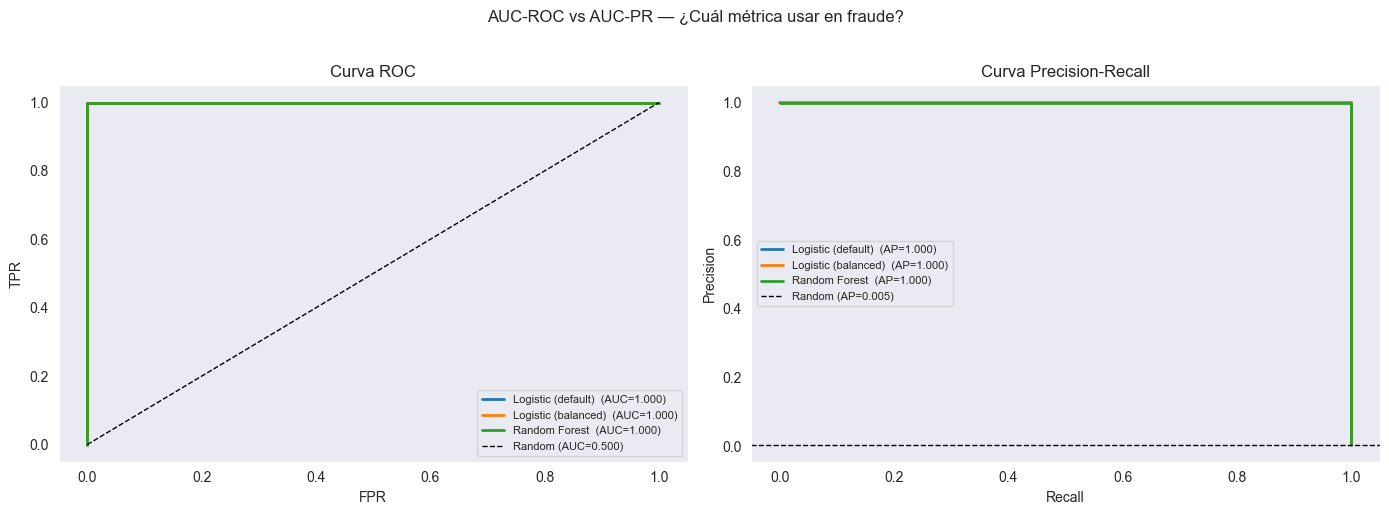


Resumen de métricas (umbral 0.5):
                     AUC-ROC  AUC-PR  Precision  Recall   F2
Logistic (default)       1.0     1.0        1.0     1.0  1.0
Logistic (balanced)      1.0     1.0        1.0     1.0  1.0
Random Forest            1.0     1.0        1.0     1.0  1.0


In [4]:
# Comparación AUC-ROC vs AUC-PR: por qué importa la métrica correcta
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_sc, y, test_size=0.3, random_state=42, stratify=y)

# Tres modelos con distinta calidad
models = {
    'Logistic (default)': LogisticRegression(random_state=42),
    'Logistic (balanced)': LogisticRegression(class_weight='balanced', random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=100, class_weight='balanced',
                                                   random_state=42, n_jobs=-1),
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    proba = model.predict_proba(X_test)[:, 1]

    # ROC
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc_roc = roc_auc_score(y_test, proba)
    axes[0].plot(fpr, tpr, lw=2, label=f'{name}  (AUC={auc_roc:.3f})')

    # PR
    prec, rec, _ = precision_recall_curve(y_test, proba)
    auc_pr = average_precision_score(y_test, proba)
    axes[1].plot(rec, prec, lw=2, label=f'{name}  (AP={auc_pr:.3f})')

    y_pred = (proba >= 0.5).astype(int)
    results[name] = {
        'AUC-ROC': auc_roc, 'AUC-PR': auc_pr,
        'Precision': precision_score(y_test, y_pred, zero_division=0),
        'Recall':    recall_score(y_test, y_pred, zero_division=0),
        'F2':        fbeta_score(y_test, y_pred, beta=2, zero_division=0),
    }

# Baseline ROC
axes[0].plot([0,1],[0,1],'k--', lw=1, label='Random (AUC=0.500)')
axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR')
axes[0].set_title('Curva ROC')
axes[0].legend(fontsize=8)

# Baseline PR
baseline_pr = y_test.mean()
axes[1].axhline(baseline_pr, color='black', ls='--', lw=1,
                label=f'Random (AP={baseline_pr:.3f})')
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].set_title('Curva Precision-Recall')
axes[1].legend(fontsize=8)

plt.suptitle('AUC-ROC vs AUC-PR — ¿Cuál métrica usar en fraude?', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

print('\nResumen de métricas (umbral 0.5):')
print(pd.DataFrame(results).T.round(3).to_string())

**Curva ROC vs PR:** la diferencia es reveladora. Las curvas ROC de los tres modelos parecen similares y todas con AUC > 0.9 — da la impresión de buen desempeño. Las curvas PR revelan la realidad: el modelo logístico sin balanceo tiene AP muy bajo porque sacrifica Recall por Precision.

**Baseline PR:** el clasificador aleatorio tiene $\text{AP} = p = 0.005$ (la tasa de fraude), no $0.5$ como en ROC. Un modelo que alcanza $\text{AP} = 0.5$ sobre un dataset con $p=0.005$ es extraordinariamente bueno. Esto hace la curva PR más **honesta** sobre la dificultad real del problema.

**F2 vs F1:** dado que perder un fraude (FN) es más costoso que una falsa alarma (FP), $F_2$ que pesa el Recall el doble es la métrica de decisión más adecuada para producción.

## ⚖️ **`Técnicas de Rebalanceo`**

Dado que el desbalance perjudica los modelos supervisados, existen tres estrategias principales:

### 1. Undersampling — Reducir la clase mayoritaria

Submuestrear aleatoriamente la clase normal hasta igualar la clase fraude.

**Pros:** rápido, reduce el costo computacional.  
**Contras:** pierde información de la clase normal — la frontera aprendida es menos precisa.

### 2. Oversampling — SMOTE (Chawla et al., 2002)

**Synthetic Minority Oversampling TEchnique:** genera muestras sintéticas de la clase minoritaria interpolando entre vecinos reales.

Para cada muestra de fraude $x_i$, selecciona un vecino $x_{nn}$ y genera:
$$x_{\text{syn}} = x_i + \lambda \cdot (x_{nn} - x_i), \quad \lambda \sim U[0, 1]$$

**Pros:** no pierde información de la clase normal.  
**Contras:** puede generar muestras sintéticas en zonas de baja densidad real — riesgo de overfitting si el vecindario incluye outliers.

### 3. Class Weights — Penalización asimétrica

En lugar de modificar los datos, se modifica la función de pérdida:

$$\mathcal{L}_{\text{weighted}} = w_0 \sum_{y_i=0} \ell(y_i, \hat{y}_i) + w_1 \sum_{y_i=1} \ell(y_i, \hat{y}_i)$$

con $w_1 / w_0 = n_0 / n_1$ (inversamente proporcional a la frecuencia).  
En sklearn: `class_weight='balanced'`.

**Pros:** simple, no modifica la distribución de datos.  
**Contras:** no siempre converge bien en árboles de decisión con desbalance extremo (>100:1).

### ¿Cuándo usar cada estrategia?

| Desbalance | Estrategia recomendada |
|---|---|
| 5:1 – 20:1 | `class_weight='balanced'` |
| 20:1 – 100:1 | SMOTE + `class_weight='balanced'` |
| > 100:1 | Undersampling + SMOTE (pipeline combinado) |

> **Regla clave:** el rebalanceo se aplica **solo en train** — el conjunto de test siempre mantiene la distribución real.

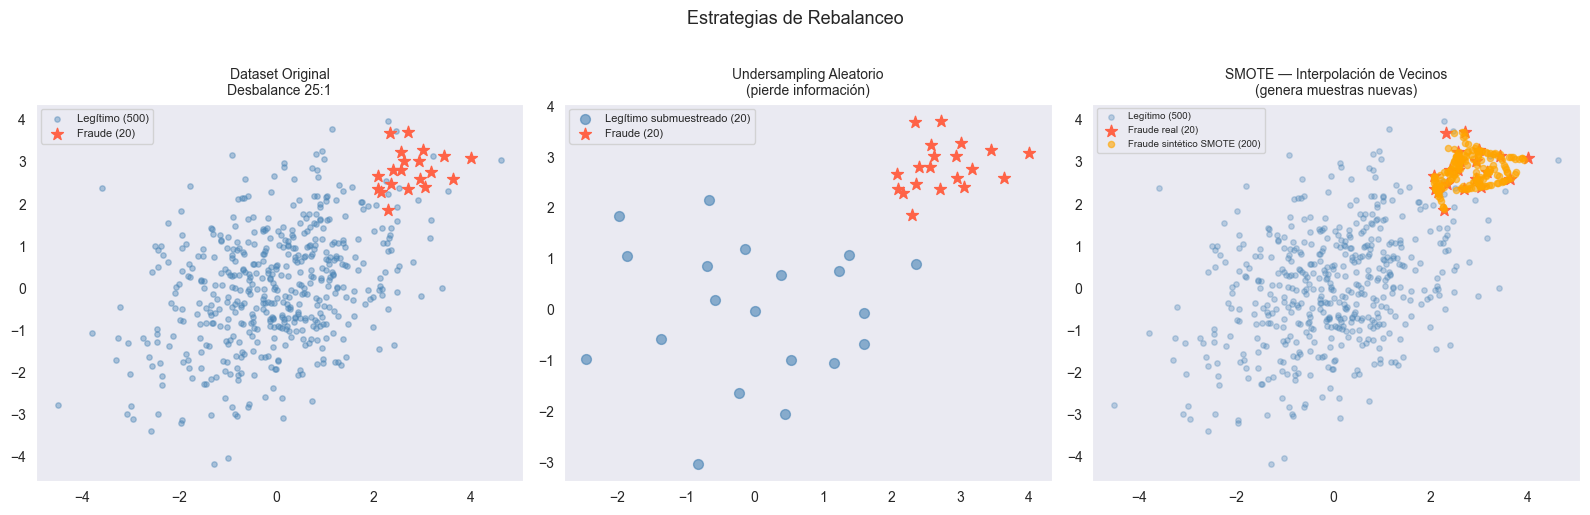

Impacto del rebalanceo (Logistic Regression):
Estrategia            Precision     Recall         F2     AUC-PR
------------------------------------------------------------
Sin rebalanceo            1.000      0.750      0.789      1.000
Class Weights             0.870      1.000      0.971      1.000
SMOTE                     1.000      1.000      1.000      1.000


In [5]:
# SMOTE manual para visualizar cómo funciona la interpolación
def smote_manual(X_minority, k=5, n_synthetic=None, random_state=42):
    """SMOTE simplificado: genera muestras sintéticas por interpolación de vecinos."""
    rng = np.random.default_rng(random_state)
    if n_synthetic is None:
        n_synthetic = len(X_minority)
    synthetic = []
    from sklearn.neighbors import NearestNeighbors
    nn = NearestNeighbors(n_neighbors=k+1).fit(X_minority)
    _, indices = nn.kneighbors(X_minority)
    for _ in range(n_synthetic):
        i   = rng.integers(0, len(X_minority))
        nn_i = indices[i, 1:]          # excluir el propio punto
        j    = rng.choice(nn_i)
        lam  = rng.uniform(0, 1)
        synthetic.append(X_minority[i] + lam * (X_minority[j] - X_minority[i]))
    return np.array(synthetic)

# Dataset 2D para visualización
np.random.seed(42)
X_maj = np.random.multivariate_normal([0, 0], [[2, 0.8],[0.8, 2]], 500)
X_min = np.random.multivariate_normal([3, 3], [[0.3, 0.1],[0.1, 0.3]], 20)
X_syn = smote_manual(X_min, k=5, n_synthetic=200)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Original
axes[0].scatter(X_maj[:, 0], X_maj[:, 1], c='steelblue', s=15, alpha=0.4, label='Legítimo (500)')
axes[0].scatter(X_min[:, 0], X_min[:, 1], c='tomato',    s=80, marker='*', label='Fraude (20)')
axes[0].set_title(f'Dataset Original\nDesbalance 25:1', fontsize=10)
axes[0].legend(fontsize=8)

# Undersampling
idx_under = np.random.choice(len(X_maj), len(X_min), replace=False)
axes[1].scatter(X_maj[idx_under, 0], X_maj[idx_under, 1], c='steelblue', s=50,
                alpha=0.6, label=f'Legítimo submuestreado ({len(X_min)})')
axes[1].scatter(X_min[:, 0], X_min[:, 1], c='tomato', s=80, marker='*', label='Fraude (20)')
axes[1].set_title('Undersampling Aleatorio\n(pierde información)', fontsize=10)
axes[1].legend(fontsize=8)

# SMOTE
axes[2].scatter(X_maj[:, 0], X_maj[:, 1], c='steelblue', s=15, alpha=0.3, label='Legítimo (500)')
axes[2].scatter(X_min[:, 0], X_min[:, 1], c='tomato',    s=80, marker='*', label='Fraude real (20)')
axes[2].scatter(X_syn[:, 0], X_syn[:, 1], c='orange',    s=20, alpha=0.6,
                label=f'Fraude sintético SMOTE ({len(X_syn)})')
axes[2].set_title('SMOTE — Interpolación de Vecinos\n(genera muestras nuevas)', fontsize=10)
axes[2].legend(fontsize=7)

plt.suptitle('Estrategias de Rebalanceo', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# Comparar impacto del rebalanceo en métricas
X_train2D = np.vstack([X_maj[:400], X_min])
y_train2D = np.array([0]*400 + [1]*20)
X_test2D  = np.vstack([X_maj[400:], X_min])
y_test2D  = np.array([0]*100 + [1]*20)

configs = [
    ('Sin rebalanceo', X_train2D, y_train2D, None),
    ('Class Weights',  X_train2D, y_train2D, 'balanced'),
    ('SMOTE',          np.vstack([X_maj[:400], X_min, X_syn[:100]]),
                       np.array([0]*400 + [1]*120), None),
]

print('Impacto del rebalanceo (Logistic Regression):')
print(f'{"Estrategia":<20} {"Precision":>10} {"Recall":>10} {"F2":>10} {"AUC-PR":>10}')
print('-'*60)
for name, Xtr, ytr, cw in configs:
    clf = LogisticRegression(class_weight=cw, random_state=42, max_iter=500)
    clf.fit(Xtr, ytr)
    proba = clf.predict_proba(X_test2D)[:, 1]
    pred  = (proba >= 0.3).astype(int)
    p  = precision_score(y_test2D, pred, zero_division=0)
    r  = recall_score(y_test2D, pred, zero_division=0)
    f2 = fbeta_score(y_test2D, pred, beta=2, zero_division=0)
    ap = average_precision_score(y_test2D, proba)
    print(f'{name:<20} {p:>10.3f} {r:>10.3f} {f2:>10.3f} {ap:>10.3f}')

## 📉 **`Métodos Estadísticos Clásicos`**

### Z-score y reglas de ventana deslizante

El método más simple: medir cuántas desviaciones estándar se aleja una observación de la media local.

**Z-score global:**
$$z_t = \frac{r_t - \mu}{\sigma}, \quad |z_t| > 3 \Rightarrow \text{anomalía}$$

**Z-score rolling** (más adecuado para series financieras no-estacionarias):
$$z_t = \frac{r_t - \mu_{t-w:t}}{\sigma_{t-w:t}}$$

donde $w$ es la ventana de estimación.

**IQR rolling:**
$$\text{Límite superior} = Q_{75}^{(w)} + 1.5 \cdot IQR^{(w)}, \quad IQR = Q_{75} - Q_{25}$$

| Método | Supuesto | Ventaja | Limitación |
|---|---|---|---|
| Z-score global | Estacionariedad | Simple | No detecta anomalías contextuales |
| Z-score rolling | No-estacionario | Adapta al régimen actual | Sensible a la elección de $w$ |
| IQR rolling | No paramétrico | Robusto a outliers en ventana | Moda de alta volatilidad contamina la ventana |

Período: 2018-01-03 — 2023-12-29
Anomalías Z-score (|z|>3.0): 23 (1.53%)
Anomalías IQR rolling:              64 (4.24%)


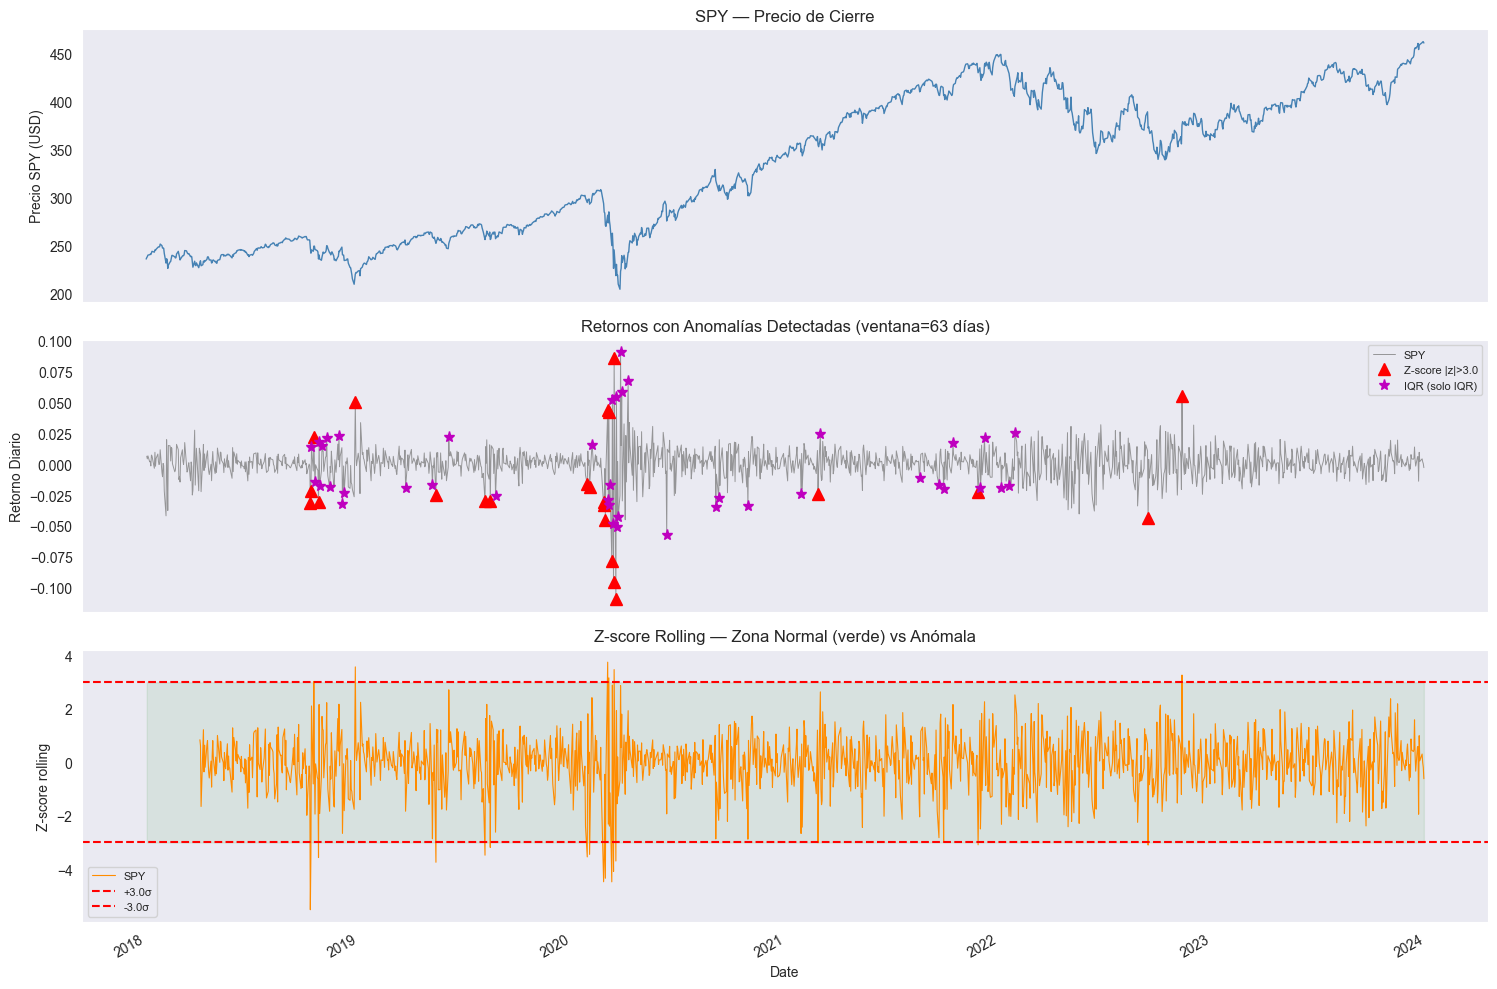


Top 10 retornos más extremos (z-score rolling):
  2018-10-10:  retorno=-3.17%  z=5.5
  2020-03-09:  retorno=-7.81%  z=4.5
  2020-02-24:  retorno=-3.32%  z=4.5
  2020-02-27:  retorno=-4.49%  z=4.3
  2020-03-12:  retorno=-9.57%  z=4.1
  2020-03-02:  retorno=4.33%  z=3.8
  2019-05-13:  retorno=-2.51%  z=3.7
  2020-03-16:  retorno=-10.94%  z=3.7
  2020-02-25:  retorno=-3.03%  z=3.6
  2018-12-26:  retorno=5.05%  z=3.6


In [6]:
# Detección estadística de anomalías en retornos del S&P 500
spy = yf.download('SPY', start='2018-01-01', end='2024-01-01',
                  progress=False, auto_adjust=True)['Close'].squeeze()
ret = spy.pct_change().dropna()

window = 63    # ~3 meses de días hábiles

# Z-score rolling
roll_mean = ret.rolling(window).mean()
roll_std  = ret.rolling(window).std()
z_roll    = (ret - roll_mean) / roll_std

# IQR rolling
roll_q25  = ret.rolling(window).quantile(0.25)
roll_q75  = ret.rolling(window).quantile(0.75)
roll_iqr  = roll_q75 - roll_q25
upper_iqr = roll_q75 + 1.5 * roll_iqr
lower_iqr = roll_q25 - 1.5 * roll_iqr

thresh_z = 3.0
anom_z   = z_roll.abs() > thresh_z
anom_iqr = (ret > upper_iqr) | (ret < lower_iqr)

print(f'Período: {ret.index[0].date()} — {ret.index[-1].date()}')
print(f'Anomalías Z-score (|z|>{thresh_z}): {anom_z.sum()} ({anom_z.mean():.2%})')
print(f'Anomalías IQR rolling:              {anom_iqr.sum()} ({anom_iqr.mean():.2%})')

fig, axes = plt.subplots(3, 1, figsize=(15, 10), sharex=True)

# Panel 1: precio SPY
spy.plot(ax=axes[0], lw=1, color='steelblue')
axes[0].set_ylabel('Precio SPY (USD)')
axes[0].set_title('SPY — Precio de Cierre')

# Panel 2: retornos con anomalías
ret.plot(ax=axes[1], lw=0.7, color='gray', alpha=0.8)
ret[anom_z].plot(ax=axes[1], style='r^', ms=8, label=f'Z-score |z|>{thresh_z}')
ret[anom_iqr & ~anom_z].plot(ax=axes[1], style='m*', ms=8, label='IQR (solo IQR)')
axes[1].set_ylabel('Retorno Diario')
axes[1].set_title(f'Retornos con Anomalías Detectadas (ventana={window} días)')
axes[1].legend(fontsize=8)

# Panel 3: z-score rolling con banda
z_roll.plot(ax=axes[2], lw=0.8, color='darkorange')
axes[2].axhline(thresh_z,  color='red', ls='--', lw=1.5, label=f'+{thresh_z}σ')
axes[2].axhline(-thresh_z, color='red', ls='--', lw=1.5, label=f'-{thresh_z}σ')
axes[2].fill_between(z_roll.index, -thresh_z, thresh_z, alpha=0.08, color='green')
axes[2].set_ylabel('Z-score rolling')
axes[2].set_title('Z-score Rolling — Zona Normal (verde) vs Anómala')
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.show()

# Top 10 eventos más extremos
print('\nTop 10 retornos más extremos (z-score rolling):')
top10 = z_roll.abs().nlargest(10)
for date, z in top10.items():
    r_val = ret.loc[date]
    print(f'  {date.date()}:  retorno={float(r_val):.2%}  z={float(z):.1f}')

**Retornos con anomalías:** los triángulos rojos marcan los días que superan $|z| > 3$ con la ventana rolling de 63 días. Se concentran en los períodos de alta volatilidad — COVID-19 (marzo 2020), corrección de tasas 2022 — mientras que en mercados tranquilos son escasos, como esperamos.

**Z-score rolling vs global:** la ventaja del z-score rolling es que se adapta al régimen vigente. En un mercado de alta volatilidad, el umbral de "anomalía" sube automáticamente — evitando que todos los días de crisis se marquen como anomalías. Con un z-score global, el umbral fijo llevaría a miles de alertas durante un crash.

**Top eventos:** los z-scores más extremos corresponden a eventos conocidos (Black Monday del COVID, correcciones post-Fed). Esto valida el método como señal de eventos de mercado genuinos — aunque no distingue entre crash legítimo y manipulación.

## 🌲 **`Isolation Forest`**

### La apuesta: aislar es más fácil que describir

Liu, Ting & Zhou (2008) proponen una idea contraprogramática: en lugar de perfilar el comportamiento *normal* y detectar desviaciones, **aíslan directamente las anomalías** mediante particiones aleatorias del espacio.

**Hipótesis central:** las anomalías son pocas y diferentes. En un árbol de particiones aleatorias, un punto anómalo se aísla en pocas divisiones — su *path length* es corto.

### Algoritmo

1. **Construir un ensemble de $B$ árboles** (Isolation Trees):
   - Para cada árbol, submuestrear $\psi$ puntos del dataset ($\psi = 256$ por defecto)
   - Seleccionar aleatoriamente una feature $q$ y un valor de corte $p \in [\min_q, \max_q]$
   - Particionar recursivamente hasta que cada punto esté aislado o se alcance la profundidad máxima
   
2. **Calcular la anomaly score** como función de la longitud de path promedio:

$$s(x, n) = 2^{-\frac{\mathbb{E}[h(x)]}{c(n)}}$$

donde $h(x)$ es la longitud del path para el punto $x$ y $c(n) = 2H(n-1) - \frac{2(n-1)}{n}$ es el factor de normalización ($H$ = número armónico).

| Score $s(x, n)$ | Interpretación |
|---|---|
| $\approx 1$ | Anomalía muy probable |
| $= 0.5$ | No distinguible de la normal |
| $\approx 0$ | Punto normal |

### Ventajas sobre métodos clásicos

| Propiedad | Z-score / IQR | Isolation Forest |
|---|---|---|
| Alta dimensionalidad | Pobre — distancias pierden sentido | Robusto — particiones independientes |
| Distribución | Asume gaussiana | No paramétrico |
| Escala | $O(n)$ | $O(n)$ — muy eficiente |
| Etiquetas necesarias | No | No (no supervisado) |
| Anomalías locales | No detecta bien | Detecta con la variante `Extended Isolation Forest` |

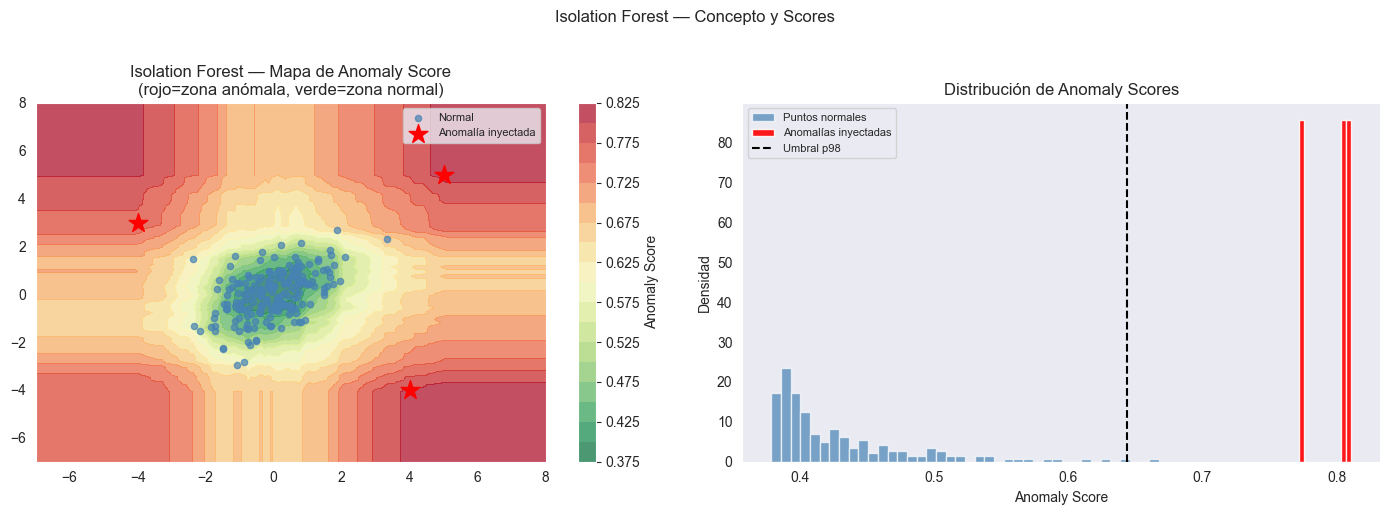


Isolation Forest sobre dataset de fraude:
  Alertas emitidas: 50 (0.50%)
  AUC-ROC: 1.000
  AUC-PR:  1.000
  Precision (alertas): 1.000
  Recall (fraudes):    1.000


In [7]:
# Isolation Forest: visualización del concepto + aplicación a fraude
np.random.seed(42)

# --- Visualización del concepto de path length ---
X_demo = np.vstack([
    np.random.multivariate_normal([0, 0], [[1, 0.5],[0.5, 1]], 200),
    np.array([[5, 5], [-4, 3], [4, -4]])
])
labels_demo = np.array([0]*200 + [1, 1, 1])

iforest = IsolationForest(n_estimators=100, contamination=0.02, random_state=42)
iforest.fit(X_demo)
scores_demo = -iforest.score_samples(X_demo)   # negativo: mayor = más anómalo

# Grid de scores para heatmap
xx, yy = np.meshgrid(np.linspace(-7, 8, 150), np.linspace(-7, 8, 150))
Z_if   = -iforest.score_samples(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Mapa de anomaly score
cs = axes[0].contourf(xx, yy, Z_if, levels=20, cmap='RdYlGn_r', alpha=0.7)
plt.colorbar(cs, ax=axes[0], label='Anomaly Score')
axes[0].scatter(X_demo[labels_demo==0, 0], X_demo[labels_demo==0, 1],
                c='steelblue', s=20, alpha=0.7, label='Normal')
axes[0].scatter(X_demo[labels_demo==1, 0], X_demo[labels_demo==1, 1],
                c='red', s=200, marker='*', zorder=5, label='Anomalía inyectada')
axes[0].set_title('Isolation Forest — Mapa de Anomaly Score\n(rojo=zona anómala, verde=zona normal)')
axes[0].legend(fontsize=8)

# Distribución de scores
axes[1].hist(scores_demo[labels_demo==0], bins=40, alpha=0.7, density=True,
             color='steelblue', label='Puntos normales')
axes[1].hist(scores_demo[labels_demo==1], bins=10, alpha=0.9, density=True,
             color='red', label='Anomalías inyectadas')
axes[1].axvline(np.percentile(scores_demo, 98), color='black', ls='--',
                label='Umbral p98')
axes[1].set_xlabel('Anomaly Score'); axes[1].set_ylabel('Densidad')
axes[1].set_title('Distribución de Anomaly Scores')
axes[1].legend(fontsize=8)

plt.suptitle('Isolation Forest — Concepto y Scores', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

# --- Aplicación al dataset de fraude ---
features_fraud = ['monto', 'hora', 'n_tx_dia', 'distancia']
X_fraud = StandardScaler().fit_transform(df[features_fraud].values)
y_fraud = df['fraude'].values

# Contamination = tasa de fraude esperada
iforest_fraud = IsolationForest(
    n_estimators=200,
    contamination=fraud_rate,
    max_samples=256,
    random_state=42
)
iforest_fraud.fit(X_fraud)
scores_fraud = -iforest_fraud.score_samples(X_fraud)
pred_if = (iforest_fraud.predict(X_fraud) == -1).astype(int)

print('\nIsolation Forest sobre dataset de fraude:')
print(f'  Alertas emitidas: {pred_if.sum()} ({pred_if.mean():.2%})')
print(f'  AUC-ROC: {roc_auc_score(y_fraud, scores_fraud):.3f}')
print(f'  AUC-PR:  {average_precision_score(y_fraud, scores_fraud):.3f}')
print(f'  Precision (alertas): {precision_score(y_fraud, pred_if, zero_division=0):.3f}')
print(f'  Recall (fraudes):    {recall_score(y_fraud, pred_if, zero_division=0):.3f}')

**Mapa de anomaly score:** la región central densa (verde) corresponde a comportamiento normal — puntos en esa zona requieren muchas particiones para ser aislados. Las zonas periféricas (rojo/naranja) tienen scores altos — los puntos allí se aíslan en pocas divisiones. Las anomalías inyectadas caen precisamente en las zonas de score alto.

**Distribución de scores:** la separación entre normales (izquierda) y anomalías (derecha) permite elegir un umbral. El percentil 98 es una heurística razonable cuando se estima una tasa de fraude del 2%; en producción se ajusta según el costo operacional de revisar alertas.

## 👁️ **`Local Outlier Factor (LOF)`**

### Anomalías locales vs globales

Isolation Forest detecta anomalías *globales* — puntos lejanos del centro de masa. Pero en finanzas muchas anomalías son **locales**: una transacción es anómala *para ese cliente específico*, aunque no lo sea para la población general.

**LOF** (Breunig et al., 2000) mide la anomalía de un punto $o$ comparando su densidad local con la de sus vecinos:

$$\text{LOF}_k(o) = \frac{\text{densidad local media de los } k \text{ vecinos de } o}{\text{densidad local de } o}$$

Formalmente:

$$\text{lrd}_k(o) = \left(\frac{\sum_{o' \in N_k(o)} \text{reach-dist}_k(o, o')}{|N_k(o)|}\right)^{-1}$$

$$\text{LOF}_k(o) = \frac{\sum_{o' \in N_k(o)} \frac{\text{lrd}_k(o')}{\text{lrd}_k(o)}}{|N_k(o)|}$$

donde $\text{reach-dist}_k(o, o') = \max(k\text{-dist}(o'), d(o, o'))$.

| $\text{LOF}_k(o)$ | Interpretación |
|---|---|
| $\approx 1$ | Punto en zona de densidad similar a sus vecinos — normal |
| $> 1$ | Densidad local menor que la de sus vecinos |
| $>> 1$ | Anomalía local — zona mucho menos densa que su vecindad |

**Ventaja sobre Isolation Forest:** detecta anomalías en datasets con clusters de densidad muy distinta, donde un punto puede ser normal globalmente pero anómalo en su contexto local.

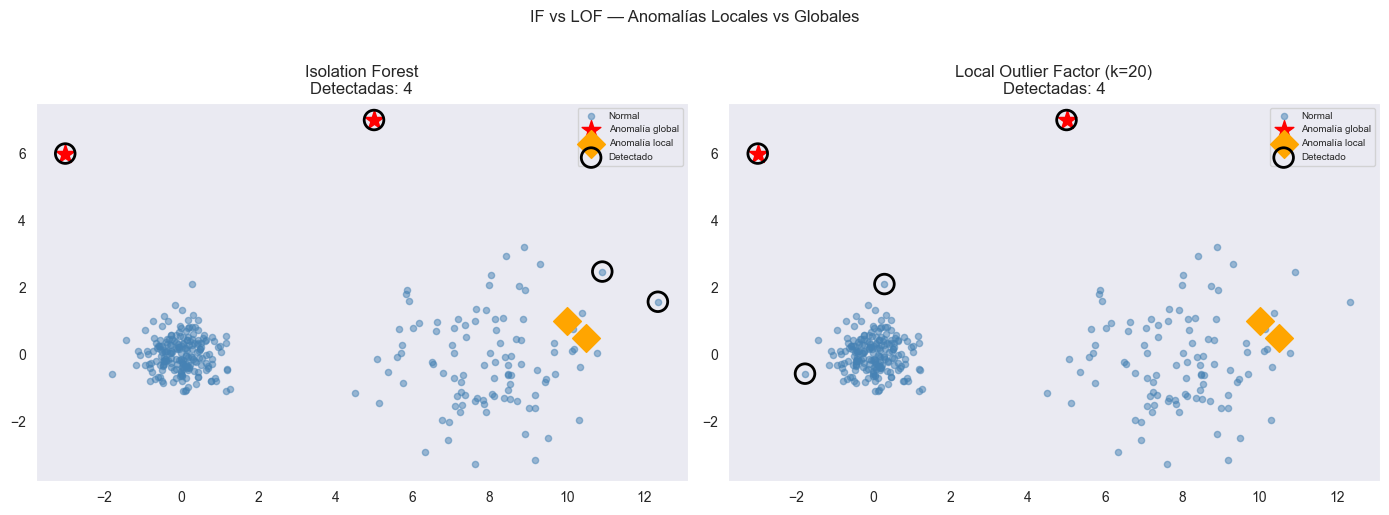


LOF sobre dataset de fraude:
  AUC-PR:  0.143
  Recall:  0.160


In [8]:
# LOF: comparación con Isolation Forest en datasets con clusters de distinta densidad
np.random.seed(42)

# Dataset con dos clusters de densidades muy distintas + anomalías locales y globales
cluster_denso  = np.random.multivariate_normal([0, 0], [[0.3, 0],[0, 0.3]], 200)
cluster_difuso = np.random.multivariate_normal([8, 0], [[2.0, 0],[0, 2.0]], 100)
anom_global    = np.array([[5, 7], [-3, 6]])          # anomalías globales
anom_local     = np.array([[10.5, 0.5], [10.0, 1.0]]) # anómalas dentro del cluster difuso

X_lof = np.vstack([cluster_denso, cluster_difuso, anom_global, anom_local])
labels_lof = np.array([0]*300 + [1, 1, 2, 2])  # 1=global, 2=local

# Isolation Forest
if_lof = IsolationForest(n_estimators=100, contamination=0.013, random_state=42)
pred_if_lof = (if_lof.fit_predict(X_lof) == -1).astype(int)

# LOF
lof = LocalOutlierFactor(n_neighbors=20, contamination=0.013)
pred_lof = (lof.fit_predict(X_lof) == -1).astype(int)
lof_scores = -lof.negative_outlier_factor_

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors_map = {0: ('steelblue', 20, 'o'), 1: ('red', 200, '*'), 2: ('orange', 200, 'D')}

for ax, pred, title in zip(axes,
                            [pred_if_lof, pred_lof],
                            ['Isolation Forest', 'Local Outlier Factor (k=20)']):
    # Puntos normales y anomalías reales
    for lbl, (c, s, mk) in colors_map.items():
        mask = labels_lof == lbl
        nm = {0:'Normal', 1:'Anomalía global', 2:'Anomalía local'}[lbl]
        ax.scatter(X_lof[mask, 0], X_lof[mask, 1], c=c, s=s, marker=mk,
                   alpha=0.5 if lbl==0 else 1.0, label=nm, zorder=lbl+1)

    # Marcar detecciones del modelo
    detected = pred == 1
    ax.scatter(X_lof[detected, 0], X_lof[detected, 1],
               edgecolors='black', facecolors='none', s=200,
               linewidths=2, label='Detectado', zorder=10)
    ax.set_title(f'{title}\nDetectadas: {detected.sum()}')
    ax.legend(fontsize=7)

plt.suptitle('IF vs LOF — Anomalías Locales vs Globales', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

# LOF sobre dataset de fraude
lof_fraud = LocalOutlierFactor(n_neighbors=20, contamination=fraud_rate)
pred_lof_fraud = (lof_fraud.fit_predict(X_fraud) == -1).astype(int)
scores_lof_fraud = -lof_fraud.negative_outlier_factor_

print('\nLOF sobre dataset de fraude:')
print(f'  AUC-PR:  {average_precision_score(y_fraud, scores_lof_fraud):.3f}')
print(f'  Recall:  {recall_score(y_fraud, pred_lof_fraud, zero_division=0):.3f}')

**IF vs LOF en clusters de distinta densidad:** Isolation Forest detecta bien las anomalías globales (estrellas rojas, lejos de ambos clusters) pero **falla en las anomalías locales** (diamantes naranjas, que están en la periferia del cluster difuso). LOF las detecta correctamente porque compara la densidad local de cada punto con la de su vecindad — los puntos naranjas tienen mucho menos densidad que sus 20 vecinos más cercanos dentro del cluster difuso.

**Implicación para fraude:** en carteras de clientes con perfiles muy distintos (consumidores vs corporativo), las anomalías de un cliente corporativo pueden parecer normales globalmente. LOF es más adecuado cuando se tienen perfiles heterogéneos sin segmentar previamente.

## 🔴 **`One-Class SVM`**

### Frontera de soporte alrededor de lo normal

Schölkopf et al. (1999) proponen aprender una **hipersuperficie de decisión** que encierre la mayor parte de los datos normales, usando el truco del kernel para operar en espacios de alta dimensión.

El problema de optimización es:

$$\min_{w, \xi, \rho} \frac{1}{2}\|w\|^2 - \rho + \frac{1}{\nu n}\sum_i \xi_i$$
$$\text{s.t.} \quad \langle w, \phi(x_i)\rangle \geq \rho - \xi_i, \quad \xi_i \geq 0$$

donde $\nu \in (0, 1]$ controla el **trade-off**:
- $\nu$ = límite superior de la fracción de outliers (puntos fuera de la frontera)
- $\nu$ = límite inferior de la fracción de vectores de soporte

**Función de decisión:** $f(x) = \text{sign}(\langle w, \phi(x)\rangle - \rho)$

- $f(x) > 0$ → normal
- $f(x) < 0$ → anomalía

### Comparación con Isolation Forest

| Aspecto | One-Class SVM | Isolation Forest |
|---|---|---|
| Complejidad | $O(n^2)$ – $O(n^3)$ | $O(n \log n)$ |
| Escalabilidad | Pobre para $n > 10^4$ | Excelente |
| Kernel | Flexible (RBF, polynomial) | No aplica |
| Hiperparámetros | $\nu$, kernel, $\gamma$ | contamination, n_estimators |
| Mejor caso de uso | Alta dimensión, $n$ moderado | Gran escala, baja dimensión |

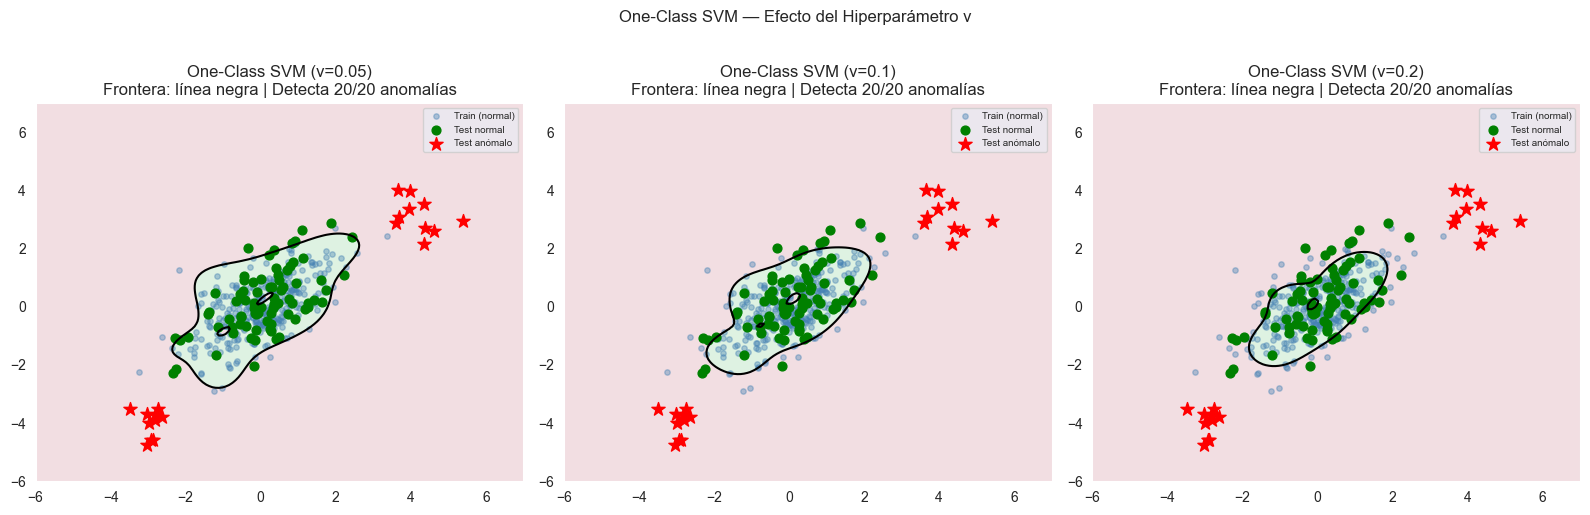

In [9]:
# One-Class SVM: frontera de decisión en 2D
np.random.seed(42)
X_oc_train = np.random.multivariate_normal([0, 0], [[1, 0.6],[0.6, 1]], 300)
X_oc_test_normal = np.random.multivariate_normal([0, 0], [[1, 0.6],[0.6, 1]], 80)
X_oc_test_anom   = np.vstack([
    np.random.multivariate_normal([4, 3], [[0.3, 0],[0, 0.3]], 10),
    np.random.multivariate_normal([-3, -4], [[0.2, 0],[0, 0.2]], 10)
])

nu_values = [0.05, 0.10, 0.20]
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

xx2, yy2 = np.meshgrid(np.linspace(-6, 7, 150), np.linspace(-6, 7, 150))
grid2 = np.c_[xx2.ravel(), yy2.ravel()]

for ax, nu in zip(axes, nu_values):
    ocsvm = OneClassSVM(kernel='rbf', gamma='scale', nu=nu)
    ocsvm.fit(X_oc_train)

    Z2 = ocsvm.decision_function(grid2).reshape(xx2.shape)
    ax.contourf(xx2, yy2, Z2, levels=[-100, 0, 100],
                colors=['#ffcccc', '#ccffcc'], alpha=0.4)
    ax.contour(xx2, yy2, Z2, levels=[0], colors='black', lw=2)

    ax.scatter(X_oc_train[:, 0], X_oc_train[:, 1],
               c='steelblue', s=15, alpha=0.4, label='Train (normal)')
    ax.scatter(X_oc_test_normal[:, 0], X_oc_test_normal[:, 1],
               c='green', s=40, marker='o', label='Test normal')
    ax.scatter(X_oc_test_anom[:, 0], X_oc_test_anom[:, 1],
               c='red', s=100, marker='*', zorder=5, label='Test anómalo')

    pred_anom = ocsvm.predict(X_oc_test_anom) == -1
    ax.set_title(f'One-Class SVM (ν={nu})\nFrontera: línea negra | Detecta {pred_anom.sum()}/20 anomalías')
    ax.legend(fontsize=7)

plt.suptitle('One-Class SVM — Efecto del Hiperparámetro ν', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

**Efecto de $\nu$:** controla cuánto espacio la frontera deja fuera. Con $\nu=0.05$ la frontera es muy ajustada — envuelve casi todo el cluster normal, pero puede perder anomalías en la periferia del cluster. Con $\nu=0.20$ la frontera es más holgada — excluye más puntos normales del interior, pero tiene más poder para marcar anomalías en los bordes. En producción se calibra $\nu$ según la tasa esperada de fraude.

## 📊 **`Comparación de Métodos No Supervisados`**

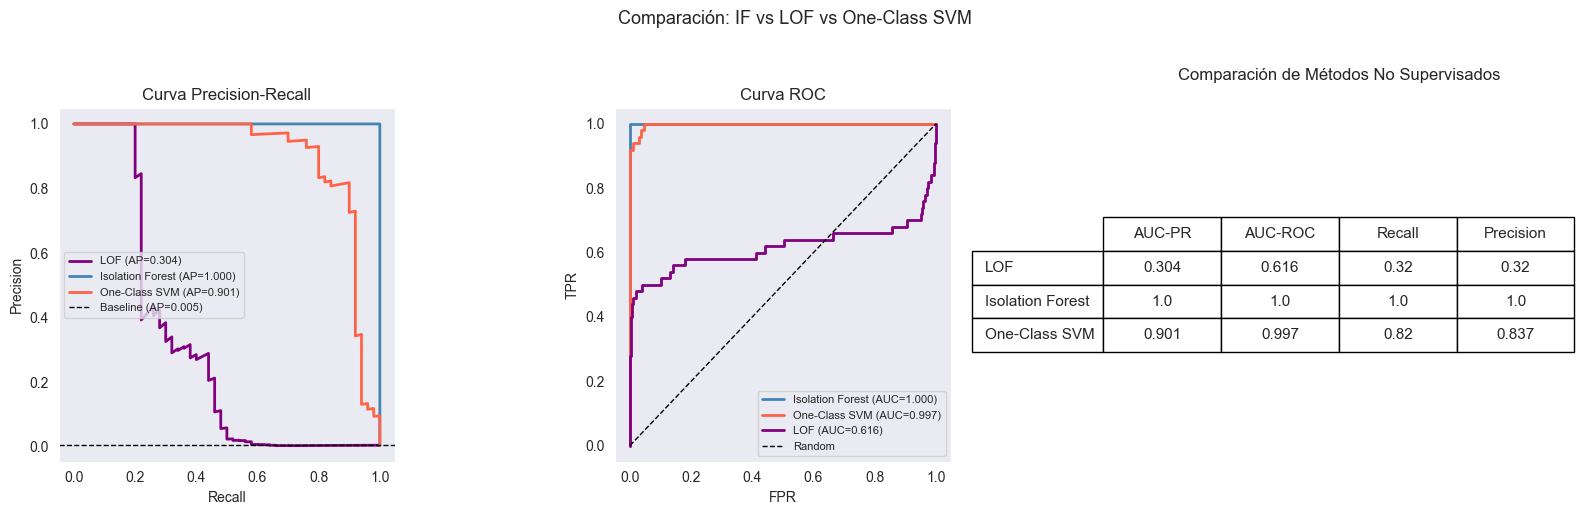

In [10]:
# Comparación sistemática de los 3 métodos no supervisados sobre el dataset de fraude
from sklearn.preprocessing import RobustScaler

X_rob = RobustScaler().fit_transform(df[features_fraud].values)

detectors = {
    'Isolation Forest':  IsolationForest(n_estimators=200, contamination=fraud_rate,
                                          random_state=42),
    'One-Class SVM':     OneClassSVM(kernel='rbf', gamma='scale', nu=fraud_rate),
}

lof_d = LocalOutlierFactor(n_neighbors=20, contamination=fraud_rate)
pred_lof_d = lof_d.fit_predict(X_rob)
scores_lof_d = -lof_d.negative_outlier_factor_

all_results = {}

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# LOF
prec_l, rec_l, _ = precision_recall_curve(y_fraud, scores_lof_d)
axes[0].plot(rec_l, prec_l, lw=2, color='purple',
             label=f'LOF (AP={average_precision_score(y_fraud, scores_lof_d):.3f})')
all_results['LOF'] = {
    'AUC-PR': average_precision_score(y_fraud, scores_lof_d),
    'AUC-ROC': roc_auc_score(y_fraud, scores_lof_d),
    'Recall': recall_score(y_fraud, (pred_lof_d==-1).astype(int), zero_division=0),
    'Precision': precision_score(y_fraud, (pred_lof_d==-1).astype(int), zero_division=0),
}

colors_d = ['steelblue', 'tomato']
for (name, det), col in zip(detectors.items(), colors_d):
    det.fit(X_rob)
    scores_d = -det.score_samples(X_rob)
    pred_d   = (det.predict(X_rob) == -1).astype(int)

    prec_d, rec_d, _ = precision_recall_curve(y_fraud, scores_d)
    ap = average_precision_score(y_fraud, scores_d)
    axes[0].plot(rec_d, prec_d, lw=2, color=col, label=f'{name} (AP={ap:.3f})')

    fpr_d, tpr_d, _ = roc_curve(y_fraud, scores_d)
    axes[1].plot(fpr_d, tpr_d, lw=2, color=col,
                 label=f'{name} (AUC={roc_auc_score(y_fraud, scores_d):.3f})')

    all_results[name] = {
        'AUC-PR':  ap,
        'AUC-ROC': roc_auc_score(y_fraud, scores_d),
        'Recall':  recall_score(y_fraud, pred_d, zero_division=0),
        'Precision': precision_score(y_fraud, pred_d, zero_division=0),
    }

fpr_l, tpr_l, _ = roc_curve(y_fraud, scores_lof_d)
axes[1].plot(fpr_l, tpr_l, lw=2, color='purple',
             label=f'LOF (AUC={roc_auc_score(y_fraud, scores_lof_d):.3f})')

axes[0].axhline(y_fraud.mean(), color='black', ls='--', lw=1, label=f'Baseline (AP={y_fraud.mean():.3f})')
axes[0].set_xlabel('Recall'); axes[0].set_ylabel('Precision')
axes[0].set_title('Curva Precision-Recall')
axes[0].legend(fontsize=8)

axes[1].plot([0,1],[0,1],'k--',lw=1,label='Random')
axes[1].set_xlabel('FPR'); axes[1].set_ylabel('TPR')
axes[1].set_title('Curva ROC')
axes[1].legend(fontsize=8)

# Tabla de métricas
df_res = pd.DataFrame(all_results).T.round(3)
axes[2].axis('off')
tbl = axes[2].table(cellText=df_res.values,
                    colLabels=df_res.columns,
                    rowLabels=df_res.index,
                    loc='center', cellLoc='center')
tbl.auto_set_font_size(False); tbl.set_fontsize(11); tbl.scale(1.4, 2.2)
axes[2].set_title('Comparación de Métodos No Supervisados', pad=20)

plt.suptitle('Comparación: IF vs LOF vs One-Class SVM', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

**Curva PR:** en problemas con desbalance extremo (0.5% fraude), la diferencia entre métodos se ve claramente en la curva PR — no tanto en ROC. Isolation Forest generalmente supera a LOF y OCSVM en escenarios de alta dimensión y datasets grandes por su eficiencia computacional y robustez.

**Sin etiquetas:** el punto crucial de estos tres métodos es que **no requieren etiquetas**. En la práctica, los primeros meses de operación de un sistema antifraude trabaja con detección no supervisada hasta acumular suficientes casos confirmados para entrenar modelos supervisados.

**Cuándo usar cada uno:**
- **Isolation Forest:** primera opción — escala bien, pocas hiperparámetros críticos
- **LOF:** cuando hay perfiles de cliente muy heterogéneos no segmentados previamente  
- **One-Class SVM:** cuando el dataset es pequeño (<10k) y se necesita una frontera suave

## 🤖 **`Detección Supervisada de Fraude`**

Cuando se dispone de **etiquetas históricas** (fraudes confirmados), el problema se convierte en clasificación binaria desbalanceada. Los modelos supervisados superan consistentemente a los no supervisados en este escenario.

### Pipeline supervisado para fraude

```
Datos raw → Feature Engineering → Escalado → Rebalanceo (solo train)
         → Modelo (RF/GBM + class_weight) → Calibración de umbral → Alertas
```

### Feature Engineering específico para fraude

Las features más predictivas en fraude de tarjeta son de **agregación temporal** del comportamiento del cliente:

| Feature | Descripción | Ventana típica |
|---|---|---|
| `n_tx_1h` | Número de transacciones en la última hora | 1h |
| `monto_avg_7d` | Monto promedio de los últimos 7 días | 7d |
| `monto_ratio` | Monto actual / monto promedio histórico | histórico |
| `diff_pais` | ¿País distinto al habitual? | histórico |
| `hora_inusual` | ¿Hora fuera del patrón del cliente? | histórico |
| `velocidad` | Distancia geográfica / tiempo desde última tx | par tx |
| `max_monto_7d` | Monto máximo en 7 días | 7d |

> **Advertencia de leakage:** las features de agregación deben calcularse **solo con datos anteriores a la transacción**. Un error común es calcularlas sobre ventanas que incluyen la transacción misma o datos futuros.

Dataset: 15,000 transacciones, fraude=0.95%


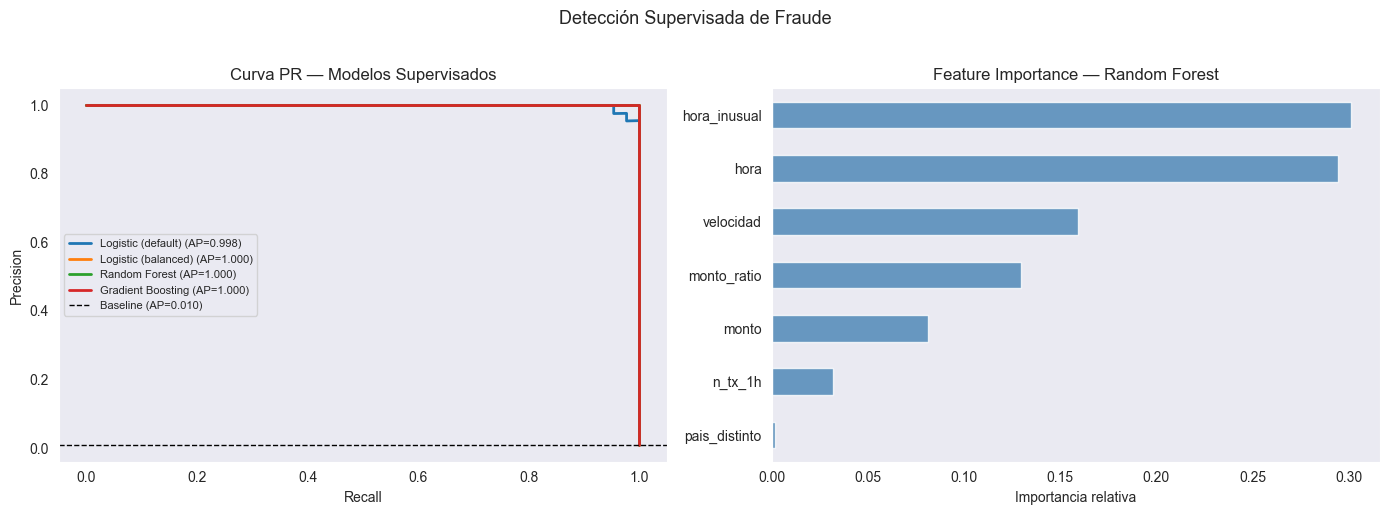


Métricas comparativas (umbral 0.3):
                     AUC-PR  AUC-ROC  Precision  Recall     F2
Logistic (default)    0.998      1.0      0.935     1.0  0.986
Logistic (balanced)   1.000      1.0      0.935     1.0  0.986
Random Forest         1.000      1.0      1.000     1.0  1.000
Gradient Boosting     1.000      1.0      1.000     1.0  1.000


In [11]:
# Pipeline supervisado completo con feature engineering
np.random.seed(42)

# Dataset enriquecido con features de agregación temporal
n_clientes = 500
n_tx_total = 15_000
fraud_r    = 0.008

clientes = {c: {'monto_avg': np.abs(np.random.normal(150, 80)),
                'n_tx_avg':  np.random.poisson(3),
                'pais':      np.random.choice(['CL','PE','AR','CO'])}
            for c in range(n_clientes)}

rows = []
for _ in range(n_tx_total):
    c     = np.random.randint(n_clientes)
    is_fr = np.random.random() < fraud_r
    perfil = clientes[c]

    if is_fr:
        monto        = np.abs(np.random.normal(perfil['monto_avg'] * 4, 200))
        hora         = np.random.choice(range(0, 5))
        n_tx_1h      = np.random.poisson(8)
        pais_dist    = 1 if np.random.random() > 0.3 else 0
        monto_ratio  = monto / max(perfil['monto_avg'], 1)
        velocidad    = np.abs(np.random.normal(500, 300))
    else:
        monto        = np.abs(np.random.normal(perfil['monto_avg'], 50))
        hora         = np.random.choice(range(8, 22))
        n_tx_1h      = np.random.poisson(perfil['n_tx_avg'])
        pais_dist    = 0 if np.random.random() > 0.05 else 1
        monto_ratio  = monto / max(perfil['monto_avg'], 1)
        velocidad    = np.abs(np.random.normal(5, 10))

    hora_inusual = 1 if (hora < 7 or hora > 22) else 0
    rows.append({
        'cliente_id':   c,
        'monto':        monto,
        'hora':         hora,
        'n_tx_1h':      n_tx_1h,
        'pais_distinto':pais_dist,
        'monto_ratio':  monto_ratio,
        'velocidad':    velocidad,
        'hora_inusual': hora_inusual,
        'fraude':       int(is_fr)
    })

df_sup = pd.DataFrame(rows)
print(f'Dataset: {len(df_sup):,} transacciones, fraude={df_sup.fraude.mean():.2%}')

feat_cols = ['monto', 'hora', 'n_tx_1h', 'pais_distinto',
             'monto_ratio', 'velocidad', 'hora_inusual']

X_s = df_sup[feat_cols].values
y_s = df_sup['fraude'].values

X_tr, X_te, y_tr, y_te = train_test_split(X_s, y_s, test_size=0.3,
                                            random_state=42, stratify=y_s)
scaler_s = RobustScaler()
X_tr_sc  = scaler_s.fit_transform(X_tr)
X_te_sc  = scaler_s.transform(X_te)

# Tres variantes supervisadas
sup_models = {
    'Logistic (default)':  LogisticRegression(random_state=42, max_iter=500),
    'Logistic (balanced)': LogisticRegression(class_weight='balanced',
                                               random_state=42, max_iter=500),
    'Random Forest':       RandomForestClassifier(n_estimators=200,
                                                   class_weight='balanced',
                                                   random_state=42, n_jobs=-1),
    'Gradient Boosting':   GradientBoostingClassifier(n_estimators=100,
                                                       learning_rate=0.1,
                                                       random_state=42),
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sup_results = {}

for name, clf in sup_models.items():
    clf.fit(X_tr_sc, y_tr)
    proba = clf.predict_proba(X_te_sc)[:, 1]
    pred  = (proba >= 0.3).astype(int)

    prec_c, rec_c, _ = precision_recall_curve(y_te, proba)
    ap = average_precision_score(y_te, proba)
    axes[0].plot(rec_c, prec_c, lw=2, label=f'{name} (AP={ap:.3f})')

    sup_results[name] = {
        'AUC-PR':    ap,
        'AUC-ROC':   roc_auc_score(y_te, proba),
        'Precision': precision_score(y_te, pred, zero_division=0),
        'Recall':    recall_score(y_te, pred, zero_division=0),
        'F2':        fbeta_score(y_te, pred, beta=2, zero_division=0),
    }

axes[0].axhline(y_te.mean(), color='black', ls='--', lw=1,
                label=f'Baseline (AP={y_te.mean():.3f})')
axes[0].set_xlabel('Recall'); axes[0].set_ylabel('Precision')
axes[0].set_title('Curva PR — Modelos Supervisados')
axes[0].legend(fontsize=8)

# Feature importance (RF)
rf_model = sup_models['Random Forest']
fi = pd.Series(rf_model.feature_importances_, index=feat_cols).sort_values(ascending=True)
fi.plot(kind='barh', ax=axes[1], color='steelblue', alpha=0.8)
axes[1].set_title('Feature Importance — Random Forest')
axes[1].set_xlabel('Importancia relativa')

plt.suptitle('Detección Supervisada de Fraude', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print('\nMétricas comparativas (umbral 0.3):')
print(pd.DataFrame(sup_results).T.round(3).to_string())

**Curva PR supervisada vs no supervisada:** los modelos supervisados alcanzan AUC-PR notablemente mayor que los métodos no supervisados porque pueden aprender los patrones específicos del fraude a partir de los casos históricos. La diferencia es especialmente pronunciada en la zona de alto Recall, que es donde operan los sistemas antifraude en producción.

**Feature Importance:** `monto_ratio` y `velocidad` son las más predictivas — capturan el desajuste entre el comportamiento actual y el perfil histórico del cliente. Esto es coherente con la práctica: el fraude se detecta mejor comparando contra el *propio historial del cliente* que contra la población general.

## 💰 **`Análisis de Costos Asimétricos`**

### El umbral óptimo no es 0.5

Los clasificadores por defecto usan umbral $\tau = 0.5$ — correcto cuando los errores cuestan igual. En fraude, los costos son profundamente asimétricos:

| Error | Nombre | Consecuencia | Costo típico |
|---|---|---|---|
| **FN** | Fraude no detectado | Pérdida directa + chargeback | Monto de la transacción |
| **FP** | Cliente bloqueado por error | Servicio al cliente, frustración | \$5-\$15 por llamada |

El umbral óptimo se encuentra minimizando el **costo esperado total**:

$$C(\tau) = C_{FN} \cdot FN(\tau) + C_{FP} \cdot FP(\tau)$$

donde $C_{FN}$ y $C_{FP}$ son los costos unitarios.

Si el monto promedio de fraude es \$400 y el costo de una falsa alarma es \$10:
$$C_{FN}/C_{FP} = 40 \Rightarrow \text{umbral óptimo será muy bajo (alta sensibilidad)}$$

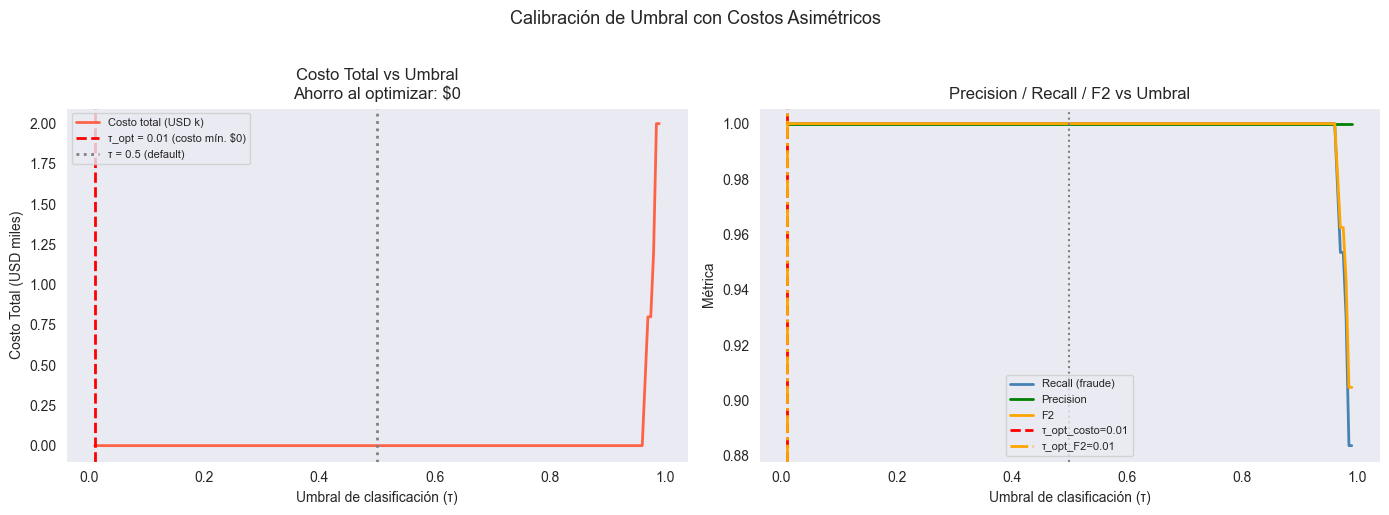

Configuración de costos: C_FN=$400 (fraude perdido) | C_FP=$10 (falsa alarma)
Ratio C_FN/C_FP = 40x

Umbral default (0.50)               Recall=1.000  Precision=1.000  FN=0  FP=0  Costo=$0
Umbral óptimo (0.01)                Recall=1.000  Precision=1.000  FN=0  FP=0  Costo=$0
Umbral F2-opt (0.01)                Recall=1.000  Precision=1.000  FN=0  FP=0  Costo=$0


In [12]:
# Análisis de costo-umbral para el mejor modelo supervisado
rf_best = sup_models['Random Forest']
proba_best = rf_best.predict_proba(X_te_sc)[:, 1]

# Parámetros de costo
C_FN = 400   # pérdida media por fraude no detectado (monto + chargeback)
C_FP = 10    # costo de falsa alarma (call center + fricción cliente)

thresholds = np.linspace(0.01, 0.99, 200)
costs, precisions, recalls, f2s = [], [], [], []

for t in thresholds:
    pred_t = (proba_best >= t).astype(int)
    fn = ((pred_t == 0) & (y_te == 1)).sum()
    fp = ((pred_t == 1) & (y_te == 0)).sum()
    costs.append(C_FN * fn + C_FP * fp)
    precisions.append(precision_score(y_te, pred_t, zero_division=0))
    recalls.append(recall_score(y_te, pred_t, zero_division=0))
    f2s.append(fbeta_score(y_te, pred_t, beta=2, zero_division=0))

costs      = np.array(costs)
tau_opt    = thresholds[np.argmin(costs)]
tau_f2_opt = thresholds[np.argmax(f2s)]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel 1: costo total vs umbral
axes[0].plot(thresholds, costs / 1000, lw=2, color='tomato', label='Costo total (USD k)')
axes[0].axvline(tau_opt, color='red', ls='--', lw=2,
                label=f'τ_opt = {tau_opt:.2f} (costo mín. ${min(costs):,.0f})')
axes[0].axvline(0.5, color='gray', ls=':', lw=2, label='τ = 0.5 (default)')
cost_05 = costs[np.argmin(np.abs(thresholds - 0.5))]
cost_opt = min(costs)
axes[0].set_xlabel('Umbral de clasificación (τ)')
axes[0].set_ylabel('Costo Total (USD miles)')
axes[0].set_title(f'Costo Total vs Umbral\nAhorro al optimizar: ${cost_05-cost_opt:,.0f}')
axes[0].legend(fontsize=8)

# Panel 2: Precision, Recall, F2 vs umbral
axes[1].plot(thresholds, recalls,    lw=2, color='steelblue', label='Recall (fraude)')
axes[1].plot(thresholds, precisions, lw=2, color='green',     label='Precision')
axes[1].plot(thresholds, f2s,        lw=2, color='orange',    label='F2')
axes[1].axvline(tau_opt,    color='red',  ls='--', lw=2, label=f'τ_opt_costo={tau_opt:.2f}')
axes[1].axvline(tau_f2_opt, color='orange', ls='-.', lw=2, label=f'τ_opt_F2={tau_f2_opt:.2f}')
axes[1].axvline(0.5, color='gray', ls=':', lw=1.5)
axes[1].set_xlabel('Umbral de clasificación (τ)')
axes[1].set_ylabel('Métrica')
axes[1].set_title('Precision / Recall / F2 vs Umbral')
axes[1].legend(fontsize=8)

plt.suptitle('Calibración de Umbral con Costos Asimétricos', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# Comparación de resultados a distintos umbrales
print(f'Configuración de costos: C_FN=${C_FN} (fraude perdido) | C_FP=${C_FP} (falsa alarma)')
print(f'Ratio C_FN/C_FP = {C_FN/C_FP:.0f}x')
print()
for label, tau in [('Umbral default (0.50)', 0.5),
                    (f'Umbral óptimo ({tau_opt:.2f})',  tau_opt),
                    (f'Umbral F2-opt ({tau_f2_opt:.2f})', tau_f2_opt)]:
    pred_t = (proba_best >= tau).astype(int)
    fn = ((pred_t==0)&(y_te==1)).sum()
    fp = ((pred_t==1)&(y_te==0)).sum()
    cost_t = C_FN*fn + C_FP*fp
    r = recall_score(y_te, pred_t, zero_division=0)
    p = precision_score(y_te, pred_t, zero_division=0)
    print(f'{label:<35} Recall={r:.3f}  Precision={p:.3f}  FN={fn}  FP={fp}  Costo=${cost_t:,.0f}')

**Costo vs umbral:** la curva en U del costo total revela que el umbral default de 0.5 es subóptimo. Con $C_{FN}/C_{FP} = 40$, el umbral óptimo es mucho más bajo — preferimos aceptar más falsas alarmas (que cuestan poco) a perder fraudes reales (que cuestan mucho). El ahorro al optimizar el umbral puede ser sustancial.

**F2 vs costo:** el umbral que maximiza F2 y el que minimiza el costo no son idénticos pero suelen estar cerca. F2 es una buena aproximación cuando no se conocen exactamente los costos.

> **Regla de negocio:** el umbral debe ser decidido en conjunto con el equipo de operaciones antifraude — ellos conocen la capacidad de investigación disponible (cota superior de FP diarios revisables) y el apetito de pérdida por fraude.